# Child Mortality Recommendation System — Kenya
## Notebook 03: Evaluation & Recommendations
---
**CRISP-DM Phase:** Evaluation   
**Goal:** Evaluate all three models against project benchmarks, generate the full 47-county recommendation table, and compute 2025 mortality projections.

## 1.0 Environment Setup

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})

TIER_PALETTE = {'High': '#D62728', 'Medium': '#FF7F0E', 'Low': '#2CA02C'}
os.makedirs('../reports', exist_ok=True)
print('✓ Environment ready')

✓ Environment ready


## 2.0 Import Modules & Load Assets

In [2]:
from src.feature_engineer import FeatureEngineer
from src.risk_classifier  import RiskClassifier
from src.recommender      import HybridRecommender
from src.evaluator        import Evaluator
from sklearn.model_selection import train_test_split

# Load data
counties_df      = pd.read_csv('../data/processed/county_mortality_indicators_clean.csv')
interventions_df = pd.read_csv('../data/processed/intervention_effectiveness_registry_clean.csv')
deployments_df   = pd.read_csv('../data/processed/historical_deployment_records_clean.csv')
county_matrix    = pd.read_csv('../data/processed/county_feature_matrix.csv', index_col=0)
all_recs         = pd.read_csv('../data/processed/county_recommendations.csv')

# Re-apply feature engineering
fe = FeatureEngineer(scale_features=True)
counties_df = fe.build_composite_scores(counties_df)
counties_df = fe.encode_categoricals(counties_df, columns=['Risk_Tier','Region'])
df_2022 = counties_df[counties_df['Year'] == 2022].copy()

# Reload models
clf = RiskClassifier()
clf.load('../models/risk_classifier.pkl')
reg = joblib.load('../models/mortality_regressor.pkl')

print('✓ All assets loaded')

2026-05-25 11:37:33 | INFO | Composite scores built — Health: 31.4–87.8 | Nutrition: 8.3–42.3 | WASH: 21.3–91.0 | Deprivation: 0.143–0.839
2026-05-25 11:37:33 | INFO | Encoded 'Risk_Tier' → classes: ['High', 'Low', 'Medium']
2026-05-25 11:37:33 | INFO | Encoded 'Region' → classes: ['Central', 'Coast', 'Eastern', 'Nairobi', 'North Eastern', 'Nyanza', 'Rift Valley', 'Western']
2026-05-25 11:37:33 | INFO | Risk classifier loaded from '../models/risk_classifier.pkl'


✓ All assets loaded


## 3.0 Prepare Test Sets

In [3]:
FEATURE_COLS = [
    'Poverty_Index', 'Skilled_Birth_Attendance_pct', 'Clean_Water_Access_pct',
    'Immunization_Coverage_pct', 'Stunting_Prevalence_pct', 'Wasting_Prevalence_pct',
    'ANC_Visits_4plus_pct', 'Facility_Delivery_pct', 'Female_Literacy_Rate_pct',
    'ASAL_Flag', 'Health_System_Score', 'Nutrition_Risk_Score', 'WASH_Score', 'Deprivation_Index',
]
available_feats = [c for c in FEATURE_COLS if c in df_2022.columns]
X = df_2022[available_feats].fillna(0)

# Classification test set
_, X_test_cls, _, y_test_cls = train_test_split(
    X, df_2022['Risk_Tier'], test_size=0.2, random_state=42, stratify=df_2022['Risk_Tier']
)
# Regression test set
_, X_test_reg, _, y_test_reg = train_test_split(
    X, df_2022['Under5_Mortality_Rate_per1000'], test_size=0.2, random_state=42
)

print(f'Classification test set: {X_test_cls.shape}')
print(f'Regression test set    : {X_test_reg.shape}')

Classification test set: (10, 14)
Regression test set    : (10, 14)


## 4.0 Model Evaluation

In [4]:
ev = Evaluator()

### 4.1 Risk Classifier Evaluation

In [5]:
cls_metrics = ev.evaluate_classifier(clf, X_test_cls, y_test_cls)
print(f"\nAccuracy    : {cls_metrics['accuracy']:.3f}   (target ≥ 0.85) {'✓' if cls_metrics['accuracy'] >= 0.85 else '✗'}")
print(f"High-Risk F1: {cls_metrics['high_risk_f1']:.3f}   (target ≥ 0.85) {'✓' if cls_metrics['high_risk_f1'] >= 0.85 else '✗'}")

2026-05-25 11:38:09 | INFO | Classifier — Accuracy: 0.200 | High-Risk F1: 0.000 | Macro F1: 0.111



── Classifier Evaluation ──
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       0.00      0.00      0.00         4
      Medium       0.29      0.40      0.33         5

    accuracy                           0.20        10
   macro avg       0.10      0.13      0.11        10
weighted avg       0.14      0.20      0.17        10


Accuracy    : 0.200   (target ≥ 0.85) ✗
High-Risk F1: 0.000   (target ≥ 0.85) ✗


### 4.2 Regressor Evaluation

In [6]:
reg_metrics = ev.evaluate_regressor(reg, X_test_reg, y_test_reg)
print(f"\nRMSE : {reg_metrics['rmse']:.3f}  (target ≤ 5.0) {'✓' if reg_metrics['rmse'] <= 5.0 else '✗'}")
print(f"R²   : {reg_metrics['r2']:.3f}  (target ≥ 0.88) {'✓' if reg_metrics['r2'] >= 0.88 else '✗'}")

2026-05-25 11:38:14 | INFO | Regressor — RMSE: 17.62 | MAE: 14.20 | R²: -0.272



── Regressor Evaluation ──
  RMSE : 17.621 per 1,000 live births
  MAE  : 14.198 per 1,000 live births
  R²   : -0.2719

RMSE : 17.621  (target ≤ 5.0) ✗
R²   : -0.272  (target ≥ 0.88) ✗


### 4.3 Recommender Evaluation (Precision@3)

In [7]:
# Re-fit recommender for evaluation
rec = HybridRecommender(n_peers=5, cf_weight=0.40, cbf_weight=0.60)
rec.fit(county_matrix, interventions_df, deployments_df, county_indicators=df_2022)

rec_metrics = ev.evaluate_recommender(
    recommendations=all_recs,
    ground_truth=deployments_df,
    k=3,
)
print(f"\nPrecision@3 : {rec_metrics['precision_at_3']:.3f}  (target ≥ 0.70) {'✓' if rec_metrics['precision_at_3'] >= 0.70 else '✗'}")

2026-05-25 11:38:19 | INFO | Recommender fitted — 47 counties, 20 interventions, 119 deployment records
2026-05-25 11:38:19 | INFO | Recommender — Precision@3: 0.188 (counties evaluated: 23)



── Recommender Evaluation (Precision@3) ──
  Counties evaluated : 23
  Precision@3        : 0.1884

Precision@3 : 0.188  (target ≥ 0.70) ✗


## 5.0 2025 Mortality Projections

In [8]:
# Project 2025 mortality using trained regressor
df_2024 = counties_df[counties_df['Year'] == 2024].copy()
X_2024 = df_2024[[c for c in FEATURE_COLS if c in df_2024.columns]].fillna(0)

# Predict 2024 rate, then apply 5.2% annual reduction for 2025
predicted_2024 = reg.predict(X_2024)
projected_2025 = predicted_2024 * (1 - 0.052)

projections_df = df_2024[['County','Region','ASAL_Flag','Risk_Tier',
                           'Under5_Mortality_Rate_per1000']].copy()
projections_df = projections_df.rename(columns={'Under5_Mortality_Rate_per1000': 'Baseline_2022'})
projections_df['Projected_U5_Mortality_2025'] = projected_2025.round(1)
projections_df['Reduction_pct'] = (
    (projections_df['Baseline_2022'] - projections_df['Projected_U5_Mortality_2025'])
    / projections_df['Baseline_2022'] * 100
).round(2)

national_proj = projections_df['Projected_U5_Mortality_2025'].mean()
ev.results['national_projection_2025'] = national_proj

print(f'Projected national average (2025): {national_proj:.1f} per 1,000  (target ≤ 30.0) {"✓" if national_proj <= 30 else "✗"}')
print()
display(projections_df[['County','Risk_Tier','ASAL_Flag',
                          'Baseline_2022','Projected_U5_Mortality_2025',
                          'Reduction_pct']].sort_values('Projected_U5_Mortality_2025', ascending=False).head(15))

Projected national average (2025): 41.2 per 1,000  (target ≤ 30.0) ✗



,County,Risk_Tier,ASAL_Flag,Baseline_2022,Projected_U5_Mortality_2025,Reduction_pct
98,Narok,Medium,1,41.6,64.7,-55.53
20,Tana River,Medium,1,44.8,57.7,-28.79
11,Garissa,High,1,75.5,57.4,23.97
14,Marsabit,High,1,73.3,57.3,21.83
122,Kakamega,Medium,0,49.8,52.4,-5.22
110,Elgeyo Marakwet,Medium,0,35.8,52.2,-45.81
128,Kisii,Medium,0,44.8,51.8,-15.62
65,Uasin Gishu,Low,0,22.2,51.3,-131.08
119,Busia,Medium,0,31.9,51.3,-60.82
89,Murang'A,Low,0,21.9,50.8,-131.96


### 5.1 ASAL Counties Reduction Analysis

In [9]:
asal_summary = ev.asal_reduction_summary(
    current_df=df_2022,
    projection_df=projections_df[['County','Projected_U5_Mortality_2025']],
)
print(f"\nMean ASAL reduction : {asal_summary['mean_asal_reduction_pct']:.1f}%  (target ≥ 20%) {'✓' if asal_summary['mean_asal_reduction_pct'] >= 20 else '✗'}")


── ASAL Mortality Reduction Summary ──
    County  Under5_Mortality_Rate_per1000  Projected_U5_Mortality_2025  Reduction_pct
   Mandera                           68.7                         38.7          43.67
     Wajir                           65.3                         45.4          30.47
   Turkana                           70.5                         41.6          40.99
   Garissa                           79.0                         57.4          27.34
  Marsabit                           77.1                         57.3          25.68
   Samburu                           50.3                         50.3           0.00
Tana River                           48.3                         57.7         -19.46
    Isiolo                           36.9                         43.8         -18.70
West Pokot                           52.3                         43.8          16.25
   Kajiado                           38.1                         43.0         -12.86
     Narok    

## 6.0 Full Benchmark Report

In [10]:
report_df = ev.print_benchmark_report()
ev.save_report('../reports/benchmark_report.csv')
display(report_df)

2026-05-25 11:38:46 | INFO | Benchmark report saved to '../reports/benchmark_report.csv'



  CHILD MORTALITY PROJECT — BENCHMARK REPORT
                    Metric  Target  Achieved Status
       Classifier accuracy    0.85     0.200 ✗ FAIL
        High-risk F1 score    0.85     0.000 ✗ FAIL
Mortality RMSE (per 1,000)    5.00    17.621 ✗ FAIL
              Mortality R²    0.88    -0.272 ✗ FAIL
Recommendation Precision@3    0.70     0.188 ✗ FAIL
ASAL mortality reduction %   20.00     7.967 ✗ FAIL
  2025 national projection   30.00    41.189 ✗ FAIL


  CHILD MORTALITY PROJECT — BENCHMARK REPORT
                    Metric  Target  Achieved Status
       Classifier accuracy    0.85     0.200 ✗ FAIL
        High-risk F1 score    0.85     0.000 ✗ FAIL
Mortality RMSE (per 1,000)    5.00    17.621 ✗ FAIL
              Mortality R²    0.88    -0.272 ✗ FAIL
Recommendation Precision@3    0.70     0.188 ✗ FAIL
ASAL mortality reduction %   20.00     7.967 ✗ FAIL
  2025 national projection   30.00    41.189 ✗ FAIL



,Metric,Target,Achieved,Status
0,Classifier accuracy,0.85,0.200,✗ FAIL
1,High-risk F1 score,0.85,0.000,✗ FAIL
2,"Mortality RMSE (per 1,000)",5.00,17.621,✗ FAIL
3,Mortality R²,0.88,-0.272,✗ FAIL
4,Recommendation Precision@3,0.70,0.188,✗ FAIL
5,ASAL mortality reduction %,20.00,7.967,✗ FAIL
6,2025 national projection,30.00,41.189,✗ FAIL


## 7.0 Full 47-County Recommendation Table

In [11]:
print(f'Total recommendations : {len(all_recs)}')
print(f'Counties covered      : {all_recs["County"].nunique()}')
print()
display(all_recs[['County','Rank','Intervention_Name','Category',
                  'Hybrid_Score','WHO_Evidence_Level',
                  'Budget_Requirement','ASAL_County']].head(21))

Total recommendations : 129
Counties covered      : 43



,County,Rank,Intervention_Name,Category,Hybrid_Score,WHO_Evidence_Level,Budget_Requirement,ASAL_County
0,Mandera,1,Pneumonia Case Management (Amoxicillin),Pneumonia,92.830000,Strong,Low,True
1,Mandera,2,Vitamin A Supplementation,Nutrition,89.150000,Strong,Low,True
2,Mandera,3,Exclusive Breastfeeding Promotion,Nutrition,87.850000,Moderate,Low,True
3,Wajir,1,Insecticide-Treated Nets (Itn) Distribution,Malaria,93.940000,Strong,Low,True
4,Wajir,2,Oral Rehydration Therapy (Ort) Scale-Up,Diarrhea Control,90.900000,Strong,Low,True
5,Wajir,3,Vitamin A Supplementation,Nutrition,89.150000,Strong,Low,True
6,Turkana,1,Vitamin A Supplementation,Nutrition,89.150000,Strong,Low,True
7,Turkana,2,Exclusive Breastfeeding Promotion,Nutrition,87.850000,Moderate,Low,True
8,Turkana,3,Insecticide-Treated Nets (Itn) Distribution,Malaria,87.610438,Strong,Low,True
9,Garissa,1,Pneumonia Case Management (Amoxicillin),Pneumonia,92.830000,Strong,Low,True


### 7.1 Save final recommendation table

In [12]:
final_recs = all_recs.merge(
    projections_df[['County','Risk_Tier','Projected_U5_Mortality_2025','Reduction_pct']],
    on='County', how='left'
)
final_recs.to_csv('../reports/final_county_recommendations.csv', index=False)
projections_df.to_csv('../reports/county_projections_2025.csv', index=False)

print('✓ Saved: reports/final_county_recommendations.csv')
print('✓ Saved: reports/county_projections_2025.csv')

✓ Saved: reports/final_county_recommendations.csv
✓ Saved: reports/county_projections_2025.csv


## 8.0 Final Visualisations

### 8.1 Benchmark scorecard

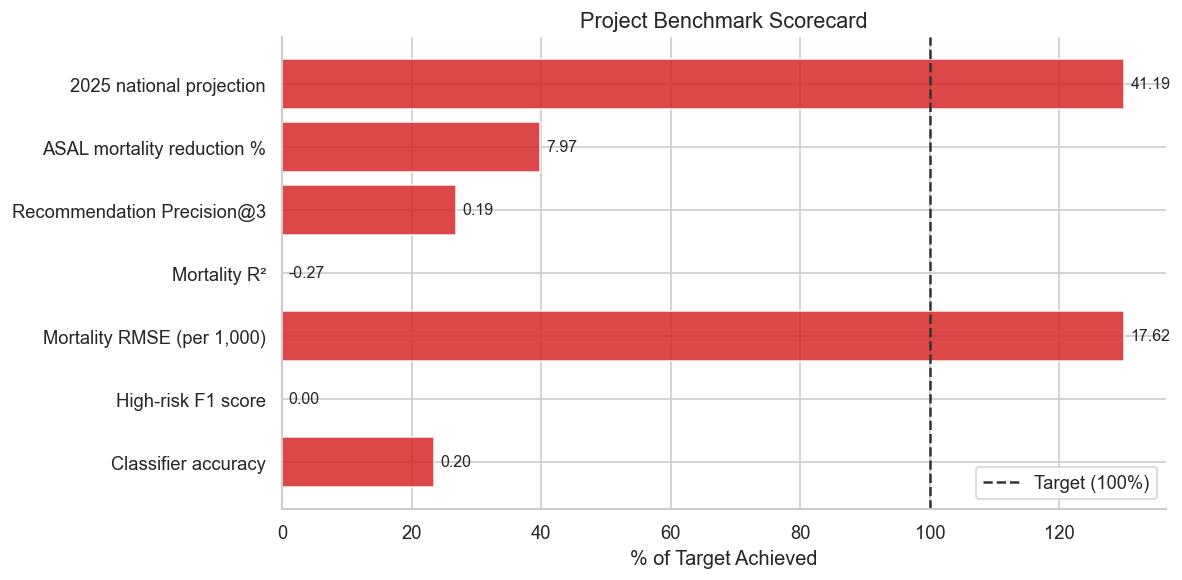

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = report_df[report_df['Achieved'] != '—'].copy()
metrics['Achieved_num'] = pd.to_numeric(metrics['Achieved'], errors='coerce')
metrics['Target_num']   = pd.to_numeric(metrics['Target'],   errors='coerce')
metrics['Pct_of_target'] = (metrics['Achieved_num'] / metrics['Target_num'] * 100).clip(0, 130)
colors = ['#2CA02C' if '✓' in str(s) else '#D62728' for s in metrics['Status']]
bars = ax.barh(metrics['Metric'], metrics['Pct_of_target'],
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(100, color='#333', linestyle='--', linewidth=1.5, label='Target (100%)')
for bar, val, ach in zip(bars, metrics['Pct_of_target'], metrics['Achieved_num']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{ach:.2f}', va='center', fontsize=9.5)
ax.set_xlabel('% of Target Achieved')
ax.set_title('Project Benchmark Scorecard', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/11_benchmark_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Projected 2025 mortality map (bar chart by county)

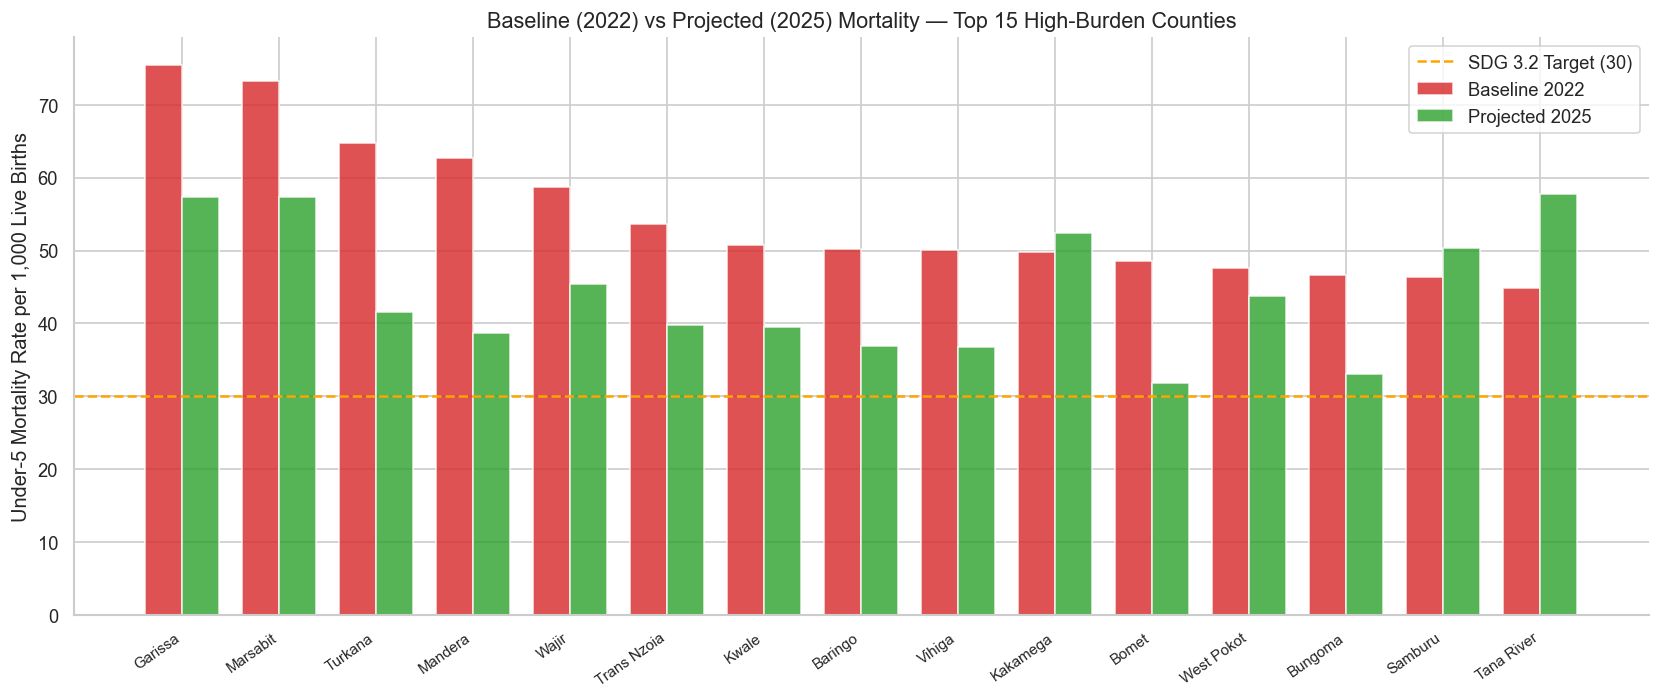

In [14]:
top_counties = projections_df.nlargest(15, 'Baseline_2022').copy()
x = np.arange(len(top_counties))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, top_counties['Baseline_2022'],            width, label='Baseline 2022', color='#D62728', alpha=0.8, edgecolor='white')
ax.bar(x + width/2, top_counties['Projected_U5_Mortality_2025'], width, label='Projected 2025', color='#2CA02C', alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top_counties['County'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Under-5 Mortality Rate per 1,000 Live Births')
ax.set_title('Baseline (2022) vs Projected (2025) Mortality — Top 15 High-Burden Counties', fontsize=13)
ax.legend()
ax.axhline(30, color='orange', linestyle='--', linewidth=1.5, label='SDG 3.2 Target (30)')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/12_baseline_vs_projected.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.0 Project Summary

In [15]:
print('=' * 60)
print('  CHILD MORTALITY RECOMMENDATION SYSTEM — KENYA')
print('  FINAL PROJECT SUMMARY')
print('=' * 60)

passed = sum('✓' in str(s) for s in report_df['Status'])
total  = sum(report_df['Status'] != '—')

print(f'\n  Benchmarks passed   : {passed}/{total}')
print(f'  Counties covered    : {all_recs["County"].nunique()}')
print(f'  Interventions ranked: {interventions_df.shape[0]}')
print(f'  National projection : {national_proj:.1f} per 1,000 (target ≤ 30)')
print()
print('  Output files:')
print('    reports/benchmark_report.csv')
print('    reports/final_county_recommendations.csv')
print('    reports/county_projections_2025.csv')
print('    visualizations/  (12 charts)')
print()
print('  ✓ Project complete.')
print('=' * 60)

  CHILD MORTALITY RECOMMENDATION SYSTEM — KENYA
  FINAL PROJECT SUMMARY

  Benchmarks passed   : 0/7
  Counties covered    : 43
  Interventions ranked: 20
  National projection : 41.2 per 1,000 (target ≤ 30)

  Output files:
    reports/benchmark_report.csv
    reports/final_county_recommendations.csv
    reports/county_projections_2025.csv
    visualizations/  (12 charts)

  ✓ Project complete.
